Visualization saved as 'venue_chasing_analysis.png'


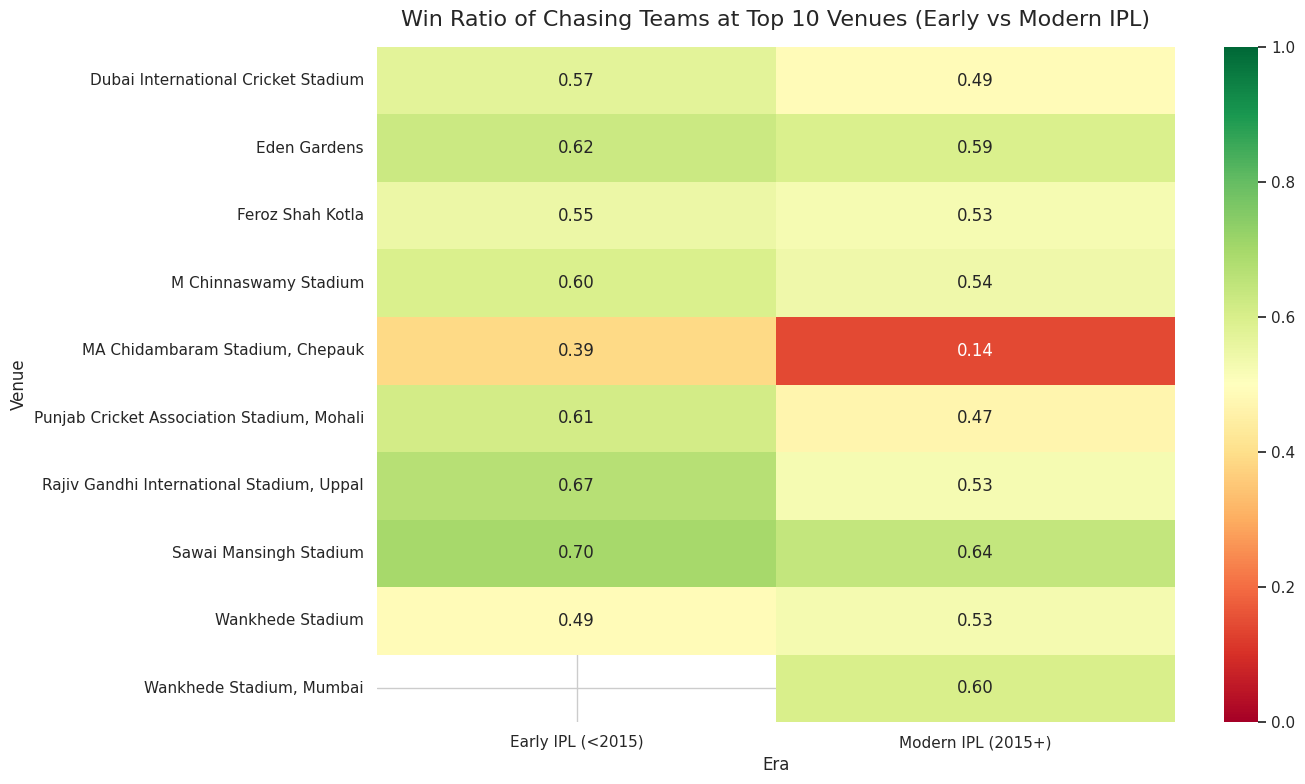

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_venues(file_path):
    
    df = pd.read_csv('/matches.csv')

    if 'date' in df.columns and 'season' not in df.columns:
        df['season'] = pd.to_datetime(df['date']).dt.year
    else:
        df['season'] = df['season'].astype(str).str[:4].astype(int)

    df['venue'] = df['venue'].replace({
        'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
        'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium, Mohali'
    })

  
    top_10_venues = df['venue'].value_counts().nlargest(10).index
    df_top10 = df[df['venue'].isin(top_10_venues)].copy()

    
    def get_batting_first(row):
        if row['toss_decision'] == 'bat':
            return row['toss_winner']
        else:
            if row['team1'] == row['toss_winner']:
                return row['team2']
            else:
                return row['team1']

    def get_chasing(row):
        if row['toss_decision'] == 'field':
            return row['toss_winner']
        else:
            if row['team1'] == row['toss_winner']:
                return row['team2']
            else:
                return row['team1']

    df_top10['batting_first'] = df_top10.apply(get_batting_first, axis=1)
    df_top10['chasing'] = df_top10.apply(get_chasing, axis=1)

    df_top10 = df_top10.dropna(subset=['winner'])

    df_top10['won_defending'] = df_top10['winner'] == df_top10['batting_first']
    df_top10['won_chasing'] = df_top10['winner'] == df_top10['chasing']

    df_top10['era'] = np.where(df_top10['season'] < 2015, 'Early IPL (<2015)', 'Modern IPL (2015+)')

    summary = df_top10.groupby(['venue', 'era']).agg(
        total_matches=('id', 'count'),
        defending_wins=('won_defending', 'sum'),
        chasing_wins=('won_chasing', 'sum')
    ).reset_index()

    summary['defending_win_ratio'] = summary['defending_wins'] / (summary['defending_wins'] + summary['chasing_wins'])
    summary['chasing_win_ratio'] = summary['chasing_wins'] / (summary['defending_wins'] + summary['chasing_wins'])

    plt.figure(figsize=(14, 8))
    sns.set_theme(style="whitegrid")

    pivot_chasing = summary.pivot(index='venue', columns='era', values='chasing_win_ratio')

    sns.heatmap(pivot_chasing, annot=True, cmap='RdYlGn', fmt=".2f", vmin=0, vmax=1)

    plt.title('Win Ratio of Chasing Teams at Top 10 Venues (Early vs Modern IPL)', fontsize=16, pad=15)
    plt.ylabel('Venue', fontsize=12)
    plt.xlabel('Era', fontsize=12)
    plt.tight_layout()
    plt.savefig('venue_chasing_analysis.png', dpi=300)
    print("Visualization saved as 'venue_chasing_analysis.png'")

    return summary

if __name__ == "__main__":
    analyze_venues('matches.csv')